# Additional Box–Jenkins Examples (Python)

**Reference**: https://www.sta.cuhk.edu.hk/nhchan/TSBook2nd/book2.html

<a target="_blank" href="https://colab.research.google.com/github/cspun/TSA/blob/main/tsa-II.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook adds **three representative real-data examples** that follow the same workflow used in the slides:

**Workflow (Box–Jenkins):**
- Plot series → detect trend / seasonality / outliers.
- Plot ACF/PACF → propose candidate structures.
- Fit models → compare AIC/BIC.
- Diagnostic checks → residual ACF + Ljung–Box.
- Forecasting → point forecasts + prediction intervals.

## Data files required (put in the same folder as this notebook)
- `yields.dat`
- `accdeaths.dat`
- `ustbill.dat`

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

## Shared helper functions
These are the **same helpers** you specified (ACF/PACF bands, residual ACF bands, ETS benchmarks, and forecasting utilities).

In [2]:
def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    # ACF
    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    # PACF
    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)   # just to be safe

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal, seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure()
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

# Example 1 — Yield of Short-term Government Securities (`yields.dat`)

### Data + Modeling Goal
- The yield series displays an upward trend.
- motivates removing the trend by **first differencing**.
- then fits an **ARIMA(0,1,1)** model (equivalently MA(1) on the differenced series).

### What to look for
- After differencing, the series should look more stationary.
- Diagnostics: residual ACF should show no serial correlation; Ljung–Box p-values should mostly exceed 0.05.

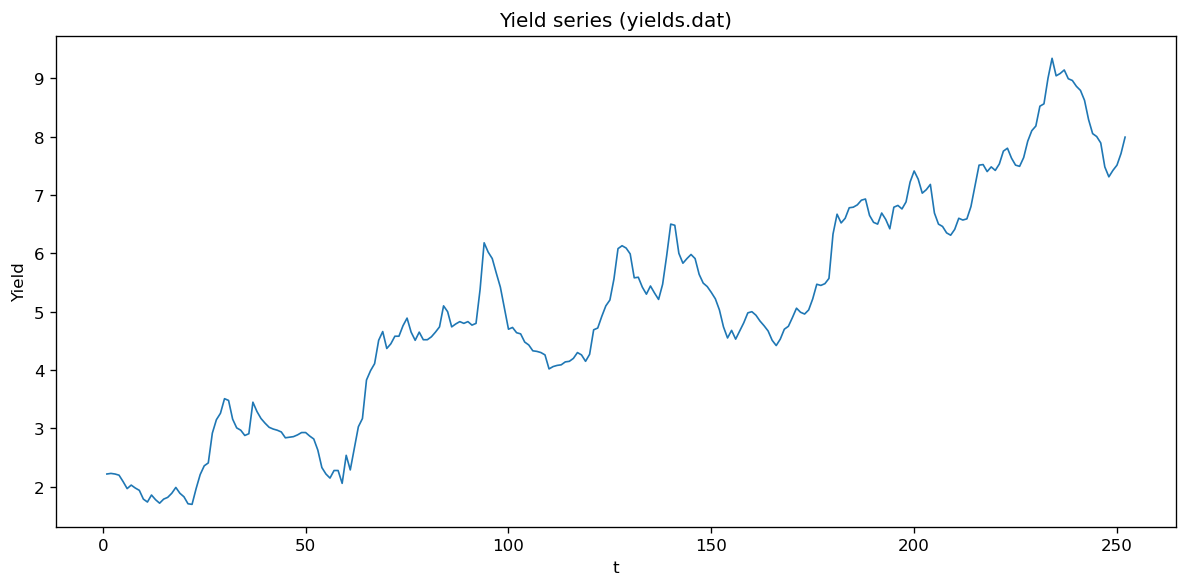

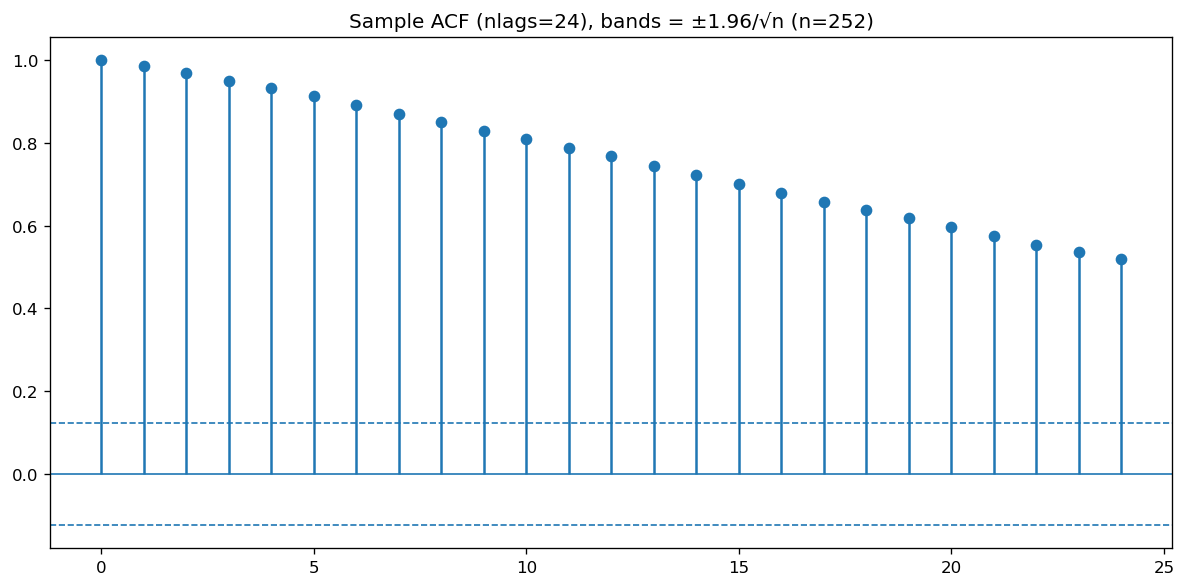

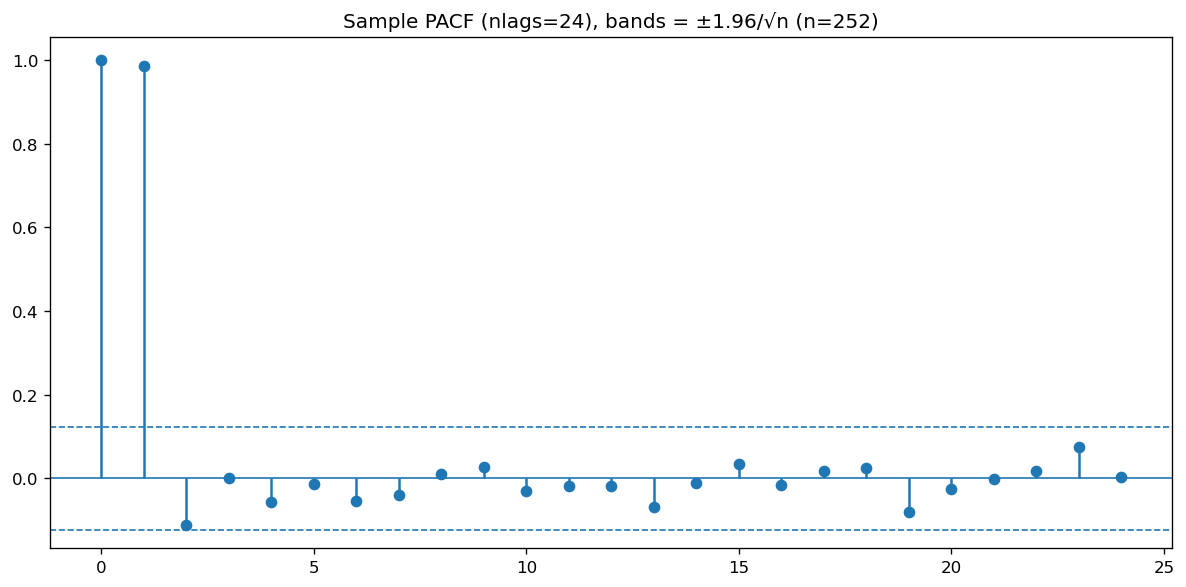

(array([1.    , 0.9855, 0.9681, 0.9506, 0.9318, 0.9126, 0.8922, 0.8707,
        0.8496, 0.8296, 0.8092, 0.7884, 0.7674, 0.7449, 0.7221, 0.7008,
        0.6793, 0.6586, 0.6391, 0.6178, 0.596 , 0.5749, 0.5545, 0.5366,
        0.5196]),
 array([ 1.    ,  0.9855, -0.1119,  0.0008, -0.0566, -0.0124, -0.0533,
        -0.0395,  0.0099,  0.0267, -0.0293, -0.019 , -0.0175, -0.0677,
        -0.0106,  0.0331, -0.017 ,  0.0187,  0.025 , -0.0802, -0.0256,
        -0.0015,  0.0176,  0.0745,  0.0024]))

In [3]:
yield_ts = np.loadtxt('yields.dat', dtype=float).flatten()
plot_series(yield_ts, 'Yield series (yields.dat)', ylabel='Yield')
plot_acf_pacf(yield_ts, nlags=24)

### Step 1: Remove trend by differencing
We compute:  
$$
W_t = Y_t - Y_{t-1}.
$$
Then examine ACF/PACF of the differenced series to decide a small ARMA candidate set.

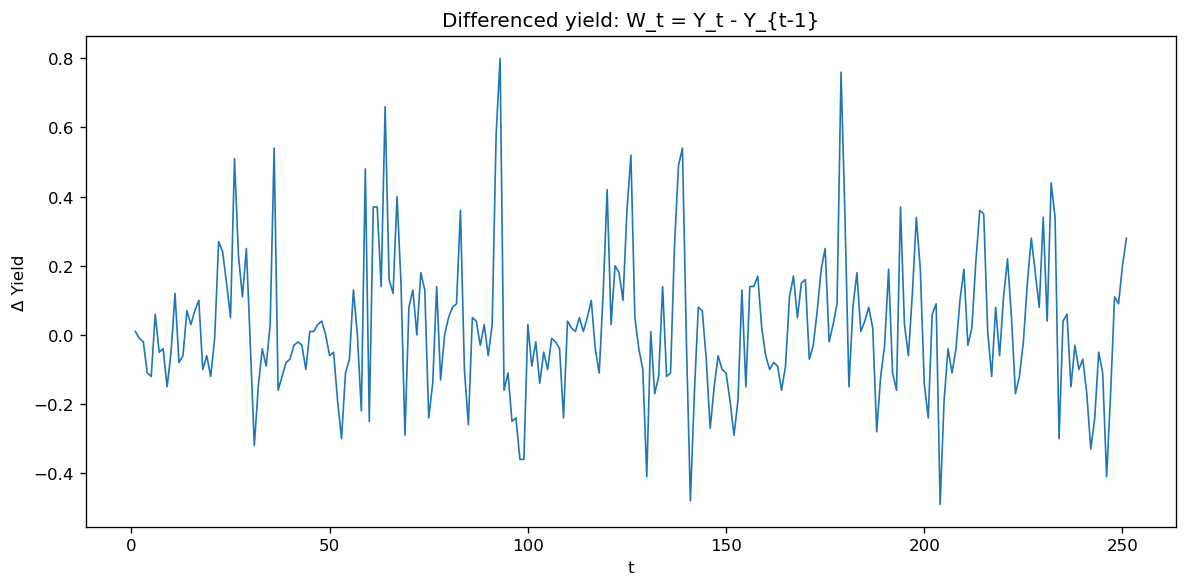

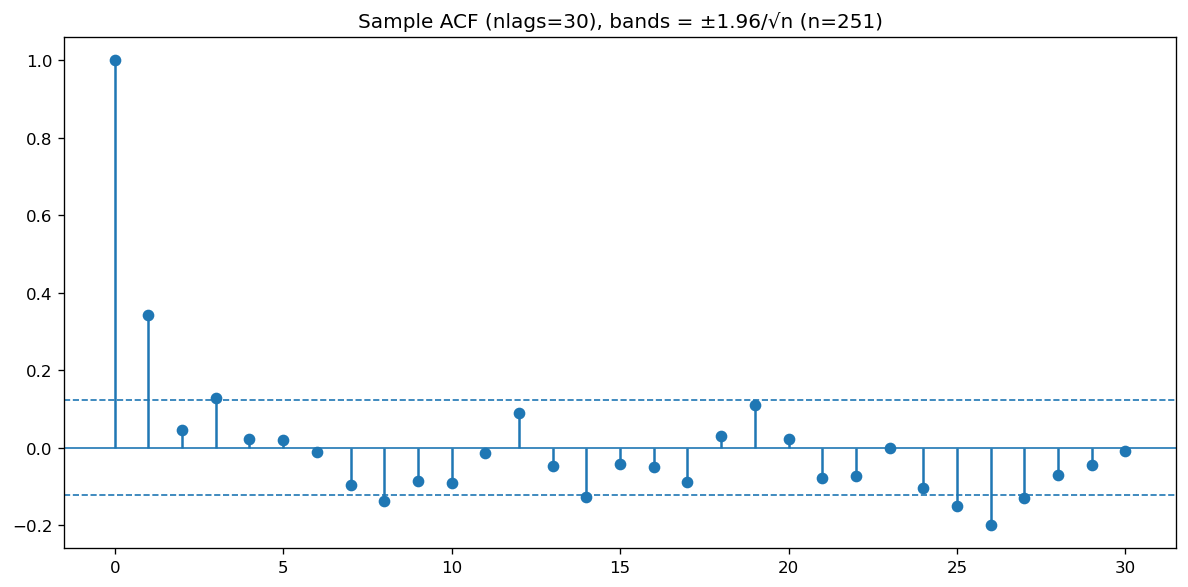

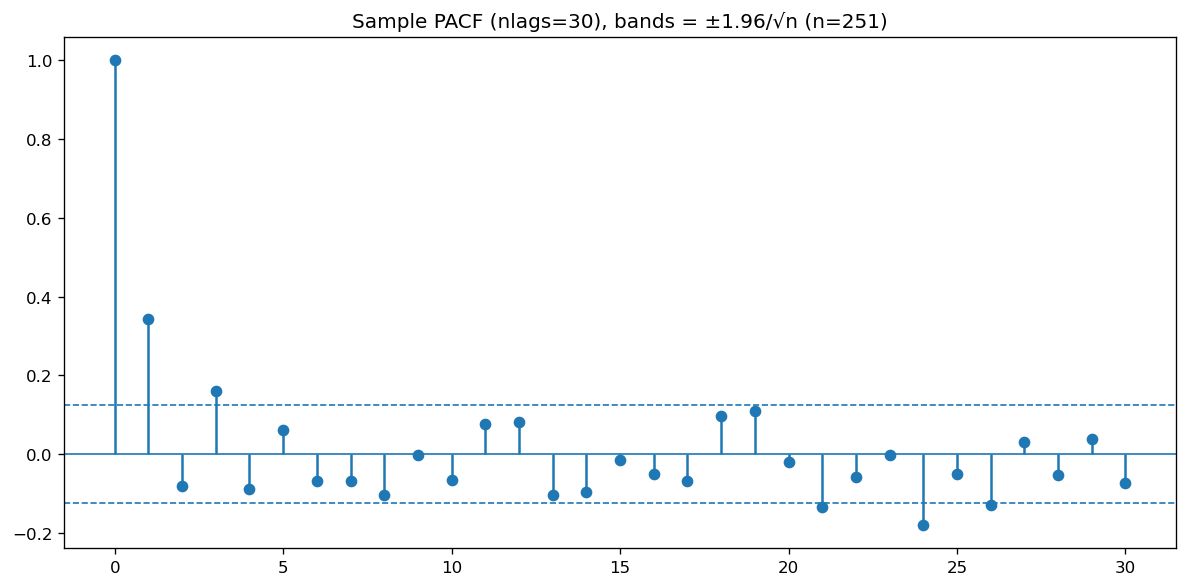

(array([ 1.    ,  0.3424,  0.0451,  0.1286,  0.0212,  0.0194, -0.0122,
        -0.0966, -0.1381, -0.0874, -0.0922, -0.0144,  0.089 , -0.0477,
        -0.1274, -0.0438, -0.0493, -0.0896,  0.0308,  0.1092,  0.0231,
        -0.0797, -0.0743,  0.    , -0.1045, -0.1503, -0.2002, -0.1304,
        -0.0709, -0.0441, -0.0092]),
 array([ 1.    ,  0.3424, -0.0817,  0.1595, -0.0893,  0.062 , -0.0696,
        -0.0677, -0.1052, -0.0019, -0.0651,  0.0764,  0.0811, -0.1028,
        -0.096 , -0.014 , -0.0508, -0.0675,  0.0967,  0.1101, -0.0206,
        -0.1335, -0.0591, -0.0022, -0.1803, -0.0514, -0.1289,  0.0317,
        -0.0535,  0.0373, -0.0746]))

In [4]:
w = np.diff(yield_ts)
plot_series(w, 'Differenced yield: W_t = Y_t - Y_{t-1}', ylabel='Δ Yield')
plot_acf_pacf(w, nlags=30)

### Step 2: Fit ARIMA(0,1,1) on the original series
In `statsmodels`, when `d=1`, we should use `trend='n'` (no constant), because a constant is eliminated by differencing.

**Interpretation:** the MA(1) coefficient is around 0.43, capturing short-run dependence in the differenced yield.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  252
Model:                 ARIMA(0, 1, 1)   Log Likelihood                  61.760
Date:                Tue, 10 Mar 2026   AIC                           -119.520
Time:                        23:48:27   BIC                           -112.469
Sample:                             0   HQIC                          -116.683
                                - 252                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4350      0.044      9.874      0.000       0.349       0.521
sigma2         0.0358      0.002     15.666      0.000       0.031       0.040
Ljung-Box (L1) (Q):                   0.26   Jarque-

,lb_stat,lb_pvalue
5,2.605408,0.760543
10,5.769148,0.834271
15,7.849167,0.929687
20,9.576854,0.975212


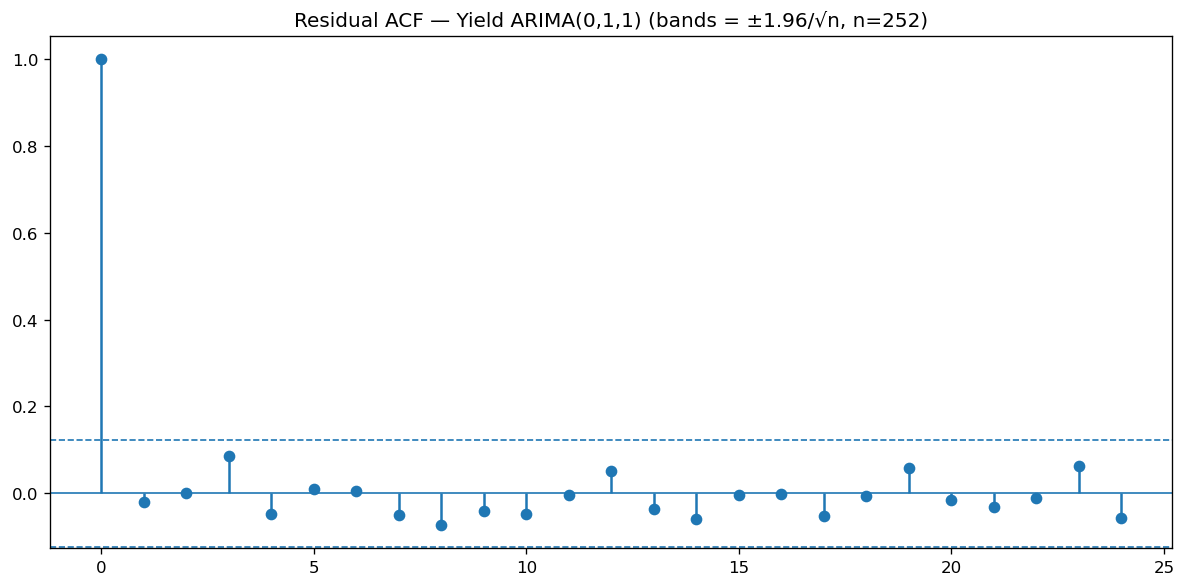

In [5]:
fit_yield = ARIMA(yield_ts, order=(0,1,1), trend='n').fit()
print(fit_yield.summary())

resid, lb = residual_report(fit_yield, lags=(5,10,15,20))
display(lb)
plot_resid_acf(resid, nlags=24, title='Residual ACF — Yield ARIMA(0,1,1)')

### Step 3: One-step-ahead prediction
We compute a one-step-ahead forecast using the MA(1) recursion and the estimated MA(1) coefficient from the fitted model.

**Interpretation:** this illustrates how the MA(1) term affects the next-step update through the estimated innovation.

In [6]:
theta = get_param(fit_yield, "ma.L1", "ma1")
n = len(yield_ts)

z_hat = np.zeros(n)
z_hat[0] = yield_ts[0]
for i in range(1, n):
    z_hat[i] = yield_ts[i] - yield_ts[i-1] - theta * z_hat[i-1]

manual_pred = yield_ts[-1] + theta * z_hat[-1]
model_pred = float(np.asarray(fit_yield.get_forecast(steps=1).predicted_mean)[0])

print('Estimated theta (MA1) =', theta)
print('Manual one-step prediction =', manual_pred)
print('Model one-step prediction  =', model_pred)

Estimated theta (MA1) = 0.4349807191457073
Manual one-step prediction = 8.077221286784981
Model one-step prediction  = 8.07722128630093


# Example 2 — Accident Deaths on U.S. Highways (`accdeaths.dat`)

### Data + Modeling Goal
- Monthly accident deaths (1973–1978).
- highlights **seasonality**: periodic component at lags 12, 24, 36, … in the ACF.
- motivates **seasonal differencing** (period 12), then possibly an additional (non-seasonal) differencing.
- compares seasonal MA vs MA(13)-type models and concludes the residual diagnostics (Ljung–Box p-values mostly > 0.05) support the final choice.

### In Python
- We fit the final model on the original monthly series:
  $$
  \text{ARIMA}(0,1,13)\times(0,1,0)_{12}
  $$
  (trend='n').

Then we do diagnostic checks and forecast 6 steps ahead.

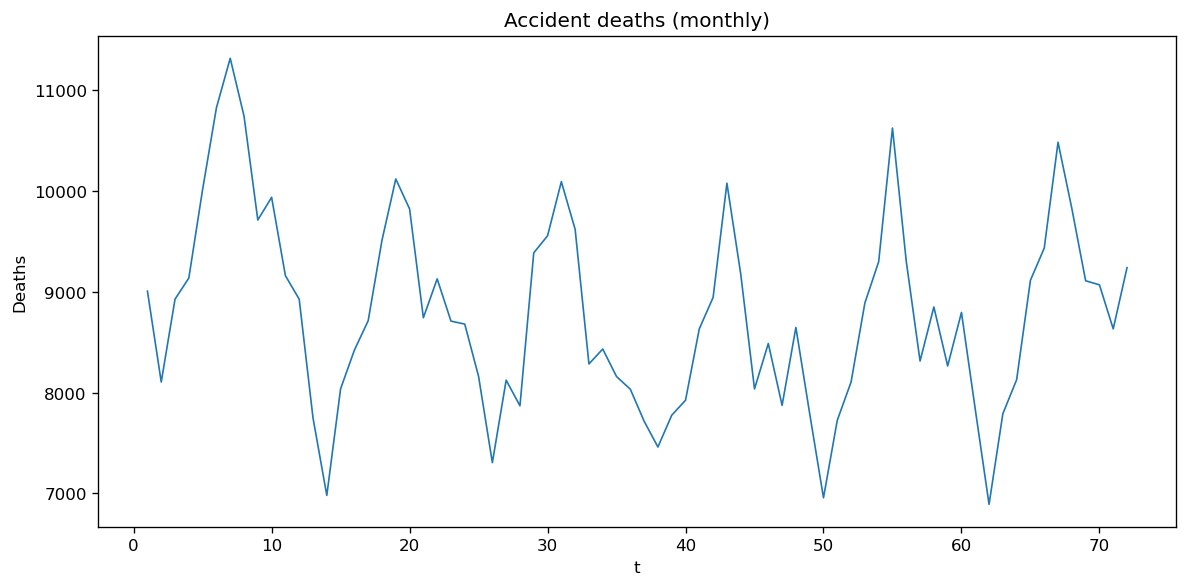

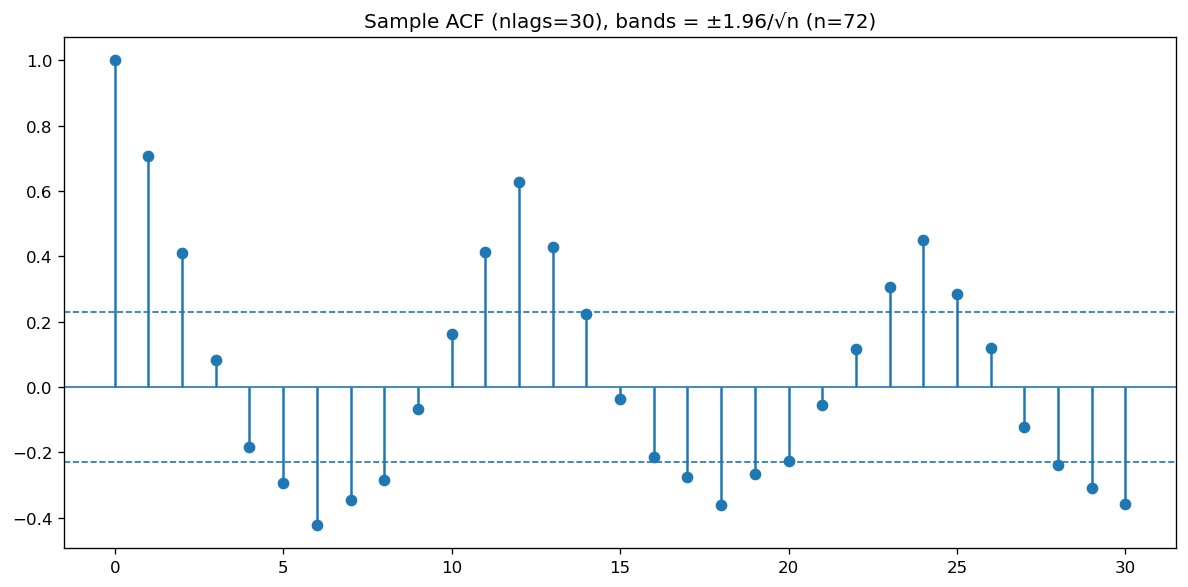

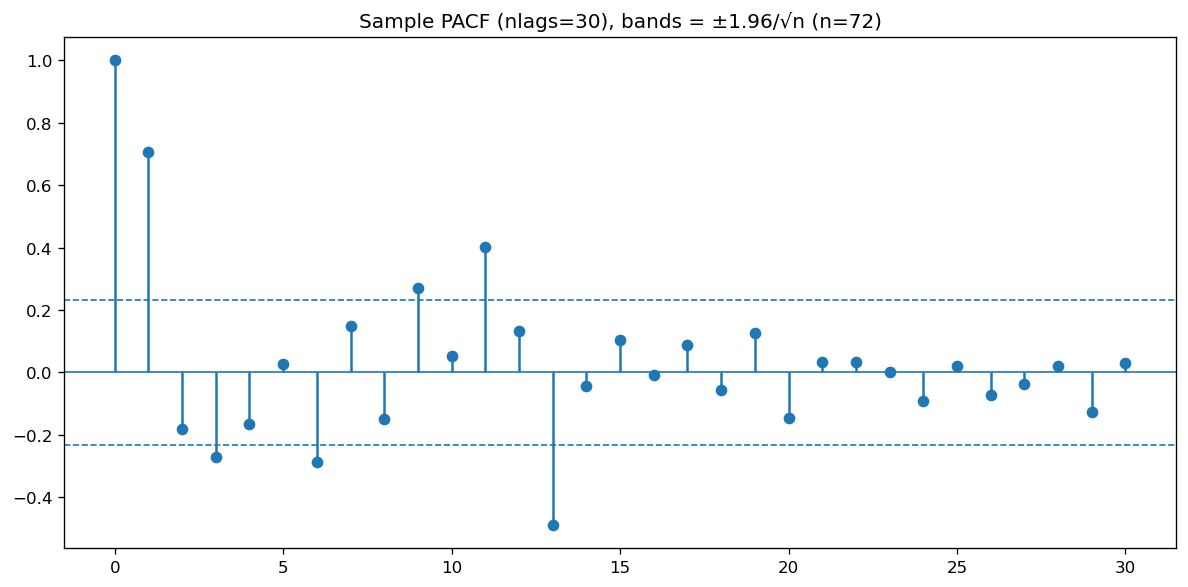

(array([ 1.    ,  0.7074,  0.4091,  0.0823, -0.1824, -0.2939, -0.4226,
        -0.3448, -0.285 , -0.067 ,  0.1614,  0.4133,  0.6282,  0.429 ,
         0.2223, -0.0376, -0.2154, -0.2757, -0.3615, -0.2664, -0.2263,
        -0.0557,  0.1155,  0.306 ,  0.4497,  0.2849,  0.119 , -0.1231,
        -0.238 , -0.3101, -0.3579]),
 array([ 1.    ,  0.7074, -0.1827, -0.2707, -0.1645,  0.0265, -0.2865,
         0.1486, -0.1497,  0.2718,  0.0531,  0.4021,  0.1333, -0.4889,
        -0.0422,  0.1051, -0.0093,  0.0894, -0.0571,  0.1249, -0.1461,
         0.0328,  0.0341,  0.0004, -0.0916,  0.022 , -0.0714, -0.0377,
         0.0195, -0.1281,  0.0299]))

In [7]:
acc = np.loadtxt('accdeaths.dat', dtype=float)
plot_series(acc, 'Accident deaths (monthly)', ylabel='Deaths')
plot_acf_pacf(acc, nlags=30)

### Seasonal differencing (period 12) + further differencing
We compute:
- Seasonal difference: $\nabla_{12}X_t = X_t - X_{t-12}$
- Further difference: $\nabla\nabla_{12}X_t$

**Interpretation:**
- If the ACF of the original series has strong seasonal peaks at multiples of 12, seasonal differencing is appropriate.
- If trend remains after seasonal differencing, another difference may be needed.

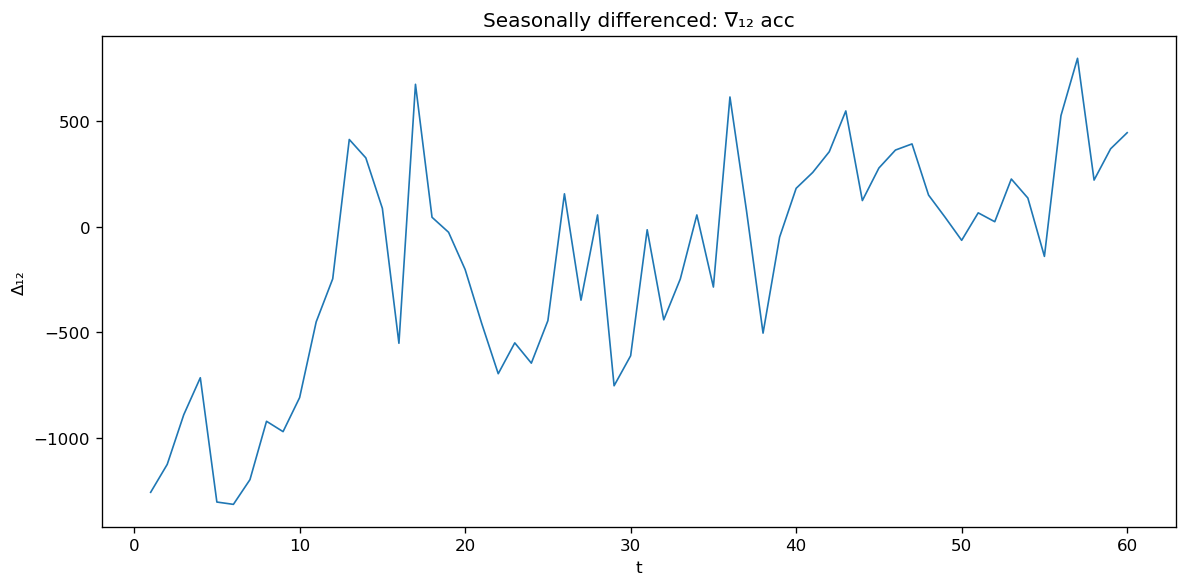

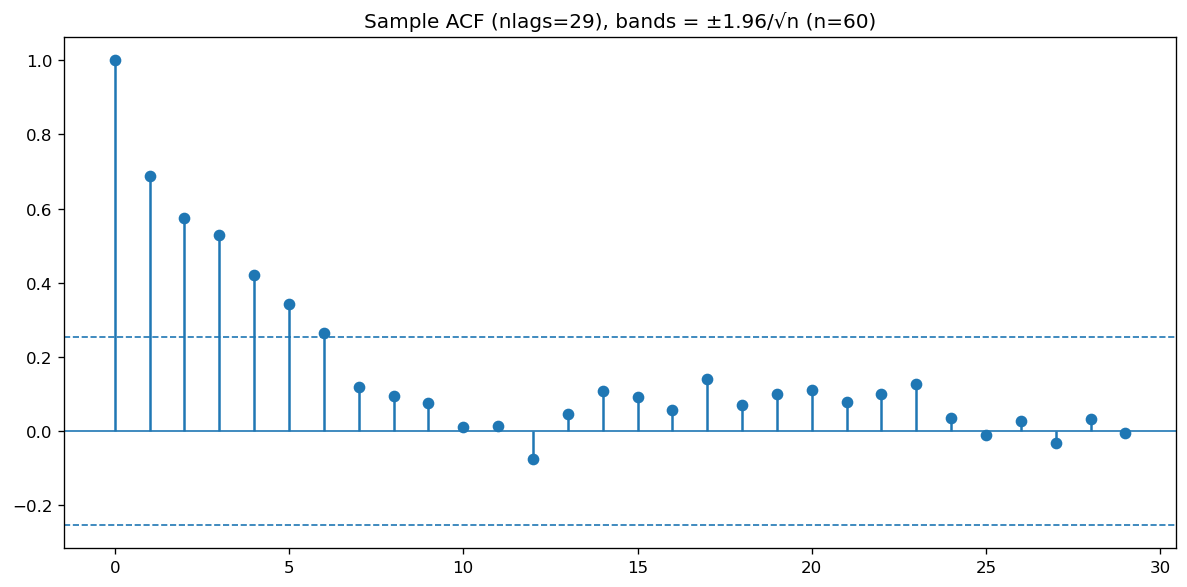

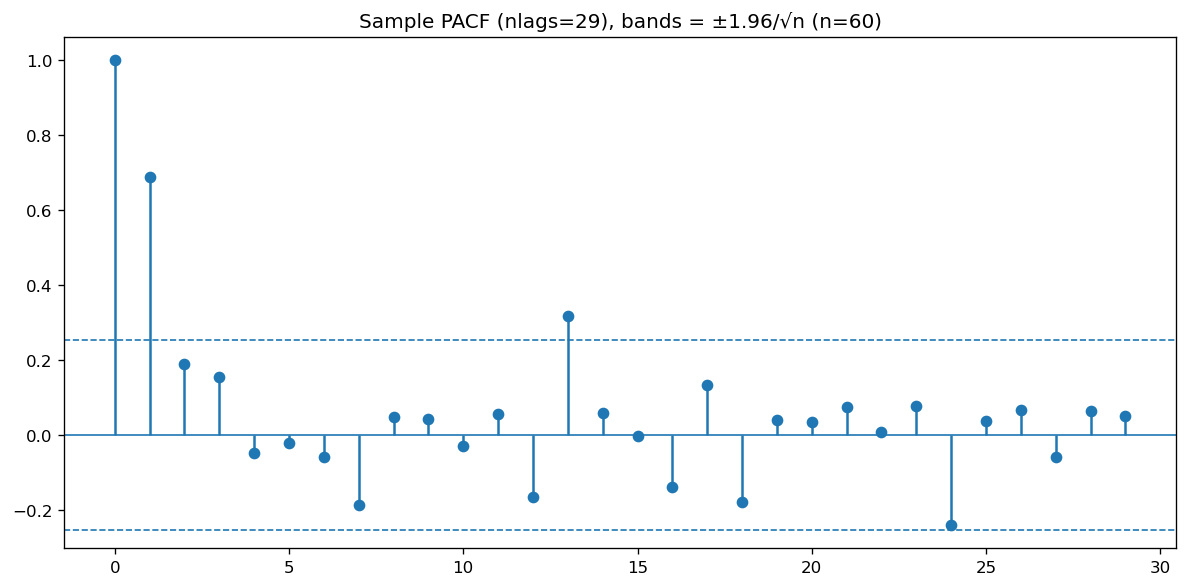

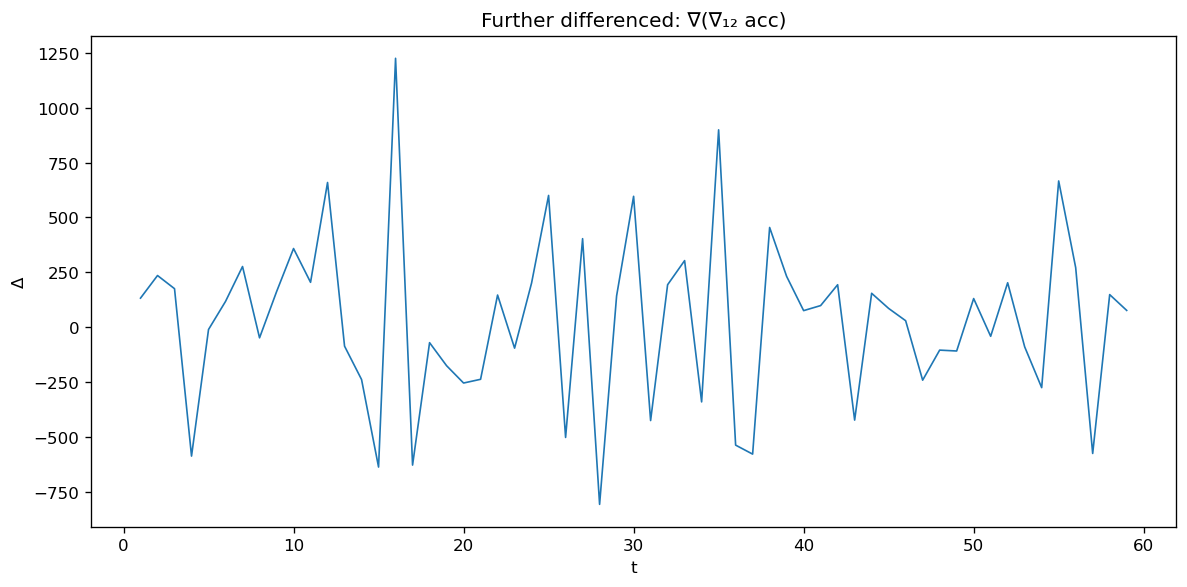

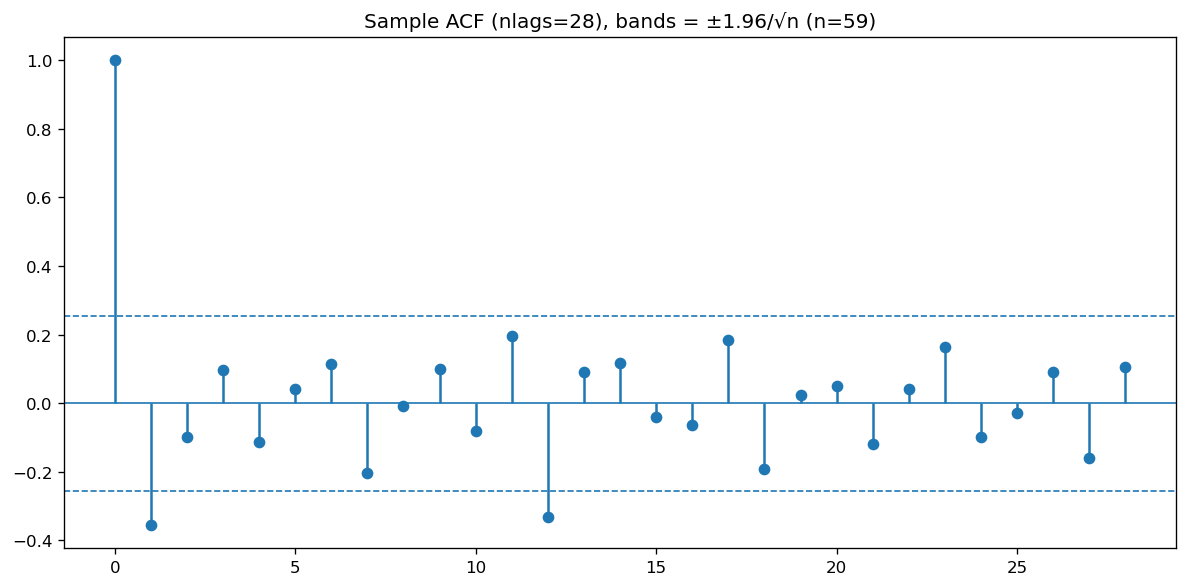

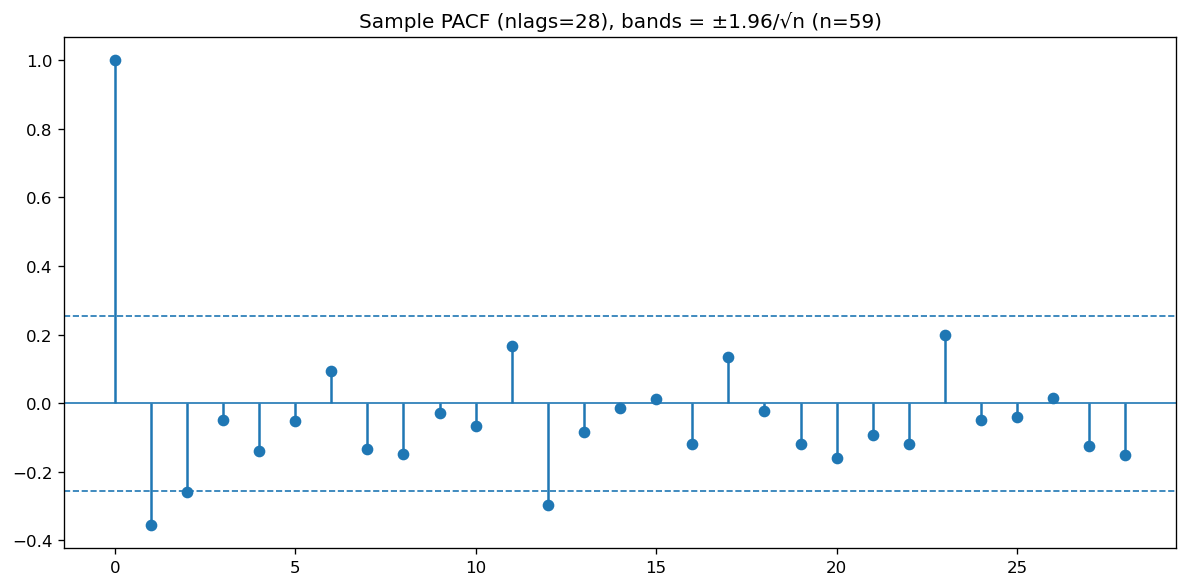

(array([ 1.    , -0.3558, -0.0987,  0.0955, -0.1125,  0.0415,  0.1141,
        -0.2041, -0.0071,  0.1001, -0.0814,  0.1952, -0.3332,  0.0902,
         0.1163, -0.0406, -0.0633,  0.1833, -0.1929,  0.0242,  0.0496,
        -0.1201,  0.0411,  0.1631, -0.0989, -0.0289,  0.0917, -0.1613,
         0.1057]),
 array([ 1.    , -0.3558, -0.258 , -0.0497, -0.14  , -0.0522,  0.0942,
        -0.1338, -0.1498, -0.029 , -0.0667,  0.1655, -0.296 , -0.0838,
        -0.015 ,  0.0119, -0.1207,  0.1359, -0.0232, -0.1189, -0.1609,
        -0.0923, -0.1192,  0.1998, -0.0482, -0.0398,  0.0147, -0.1265,
        -0.1507]))

In [8]:
dacc = acc[12:] - acc[:-12]
plot_series(dacc, 'Seasonally differenced: ∇₁₂ acc', ylabel='Δ₁₂')
plot_acf_pacf(dacc, nlags=30)

ddacc = np.diff(dacc)
plot_series(ddacc, 'Further differenced: ∇(∇₁₂ acc)', ylabel='Δ')
plot_acf_pacf(ddacc, nlags=30)

### Fit the final model on the original series
We fit:
$$
\text{ARIMA}(0,1,13)\times(0,1,0)_{12}
$$
and check:
- residual ACF (should show no serial correlation)
- Ljung–Box (p-values mostly > 0.05 supports whiteness).

C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   72
Model:             ARIMA(0, 1, 13)x(0, 1, [], 12)   Log Likelihood                -419.575
Date:                            Tue, 10 Mar 2026   AIC                            867.149
Time:                                    23:48:33   BIC                            896.235
Sample:                                         0   HQIC                           878.503
                                             - 72                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3649      2.120     -0.172      0.863      -4.520       3.790
ma.L2          0.0259      2.710   

,lb_stat,lb_pvalue
12,22.147852,0.035896
18,23.062587,0.188196
24,23.407913,0.495837
30,24.644586,0.742113


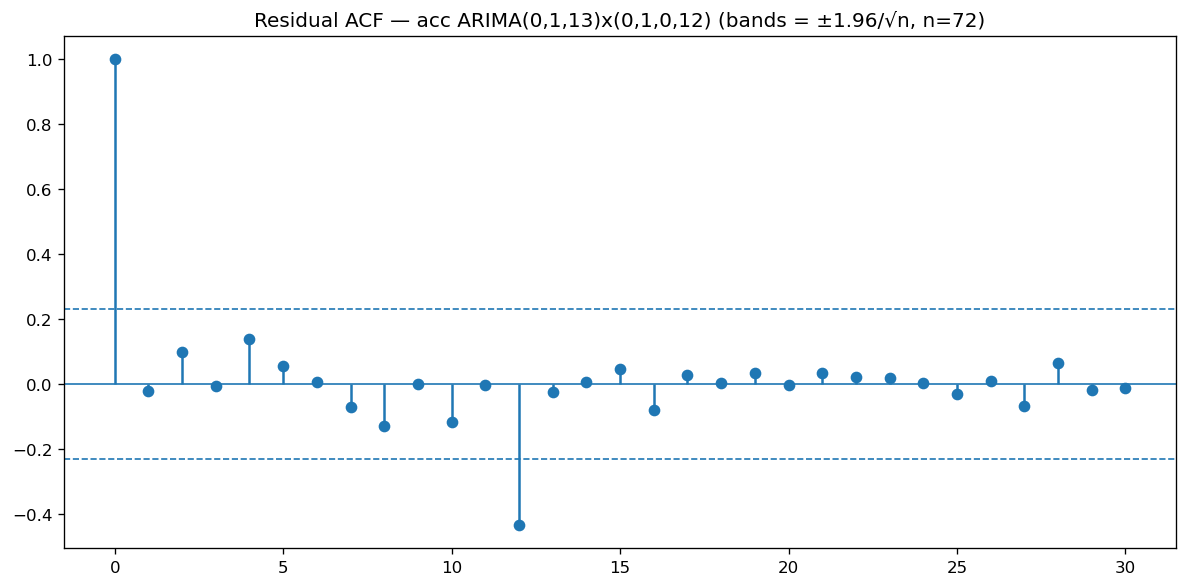

In [9]:
fit_acc = ARIMA(acc, order=(0,1,13), seasonal_order=(0,1,0,12), trend='n').fit()
print(fit_acc.summary())

resid_a, lb_a = residual_report(fit_acc, lags=(12,18,24,30))
display(lb_a)
plot_resid_acf(resid_a, nlags=30, title='Residual ACF — acc ARIMA(0,1,13)x(0,1,0,12)')

### Forecast 6 months ahead
**Interpretation:** forecasts become less accurate as the horizon increases because prediction variability grows with time.

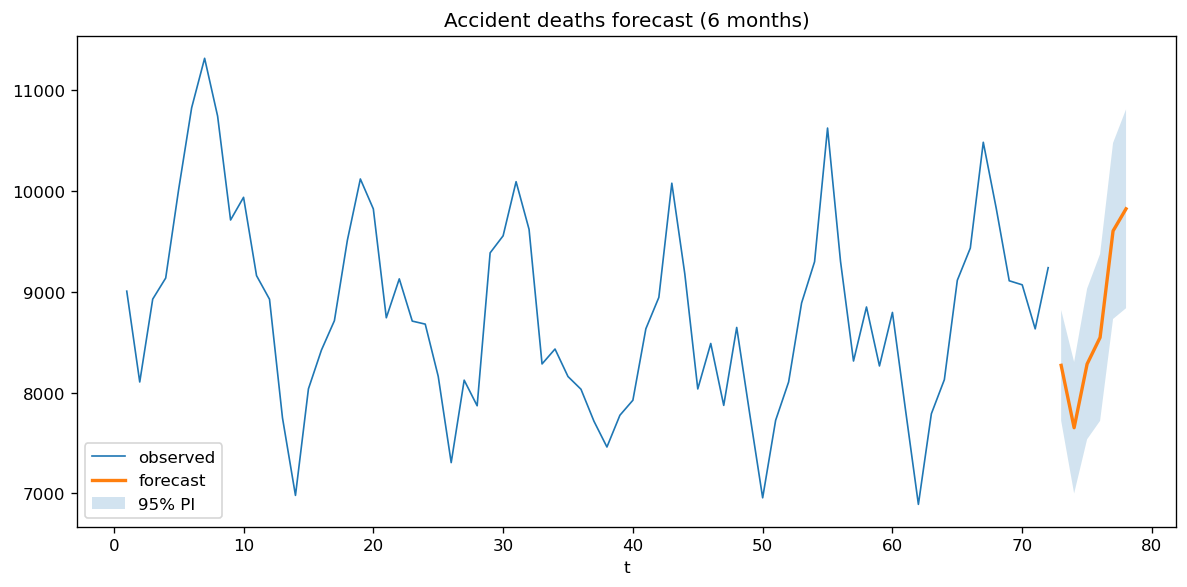

,forecast,lower_95,upper_95
73,8271.127627,7722.194206,8820.061048
74,7652.185942,6999.795249,8304.576636
75,8284.264191,7536.971082,9031.557301
76,8547.383993,7720.257903,9374.510083
77,9604.334935,8731.035309,10477.634562
78,9823.875411,8837.477528,10810.273294


In [10]:
fc_acc = forecast_table_and_plot(fit_acc, steps=6, y=acc, title_prefix='Accident deaths forecast (6 months)')
fc_acc

### Forecasting benchmark (seasonal baseline)
A strong practical benchmark for seasonal monthly data is Holt–Winters with seasonal period 12.
This provides a non-ARIMA reference forecast.


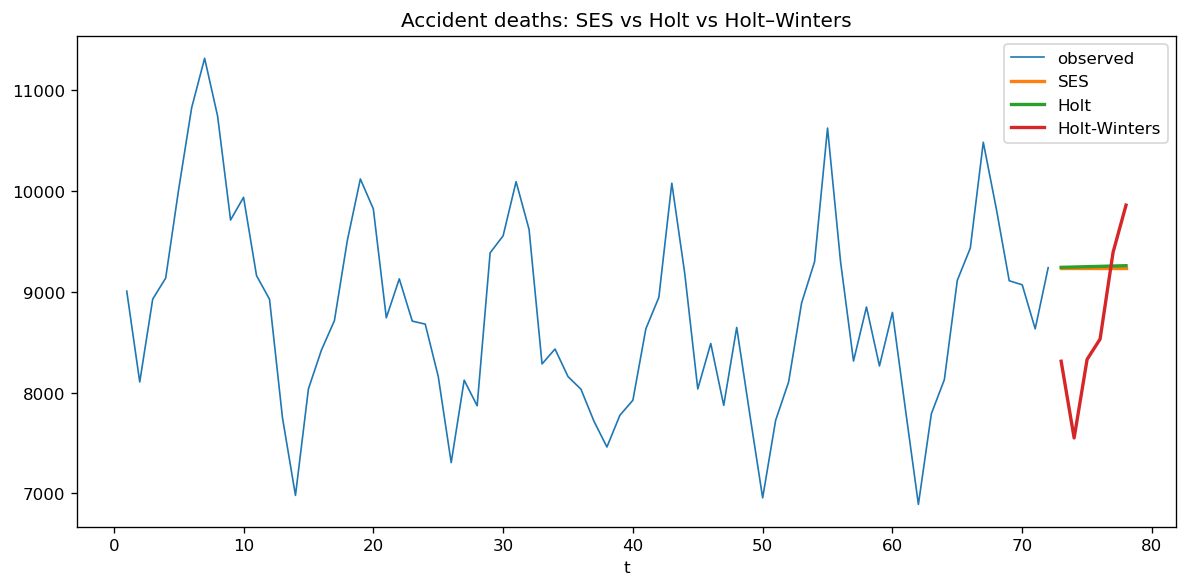

In [11]:
ses_a, holt_a, hw_a = ets_benchmarks(acc, seasonal_periods=12, seasonal='add')
plot_ets_forecasts(acc, steps=6, ses=ses_a, holt=holt_a, hw=hw_a, title='Accident deaths: SES vs Holt vs Holt–Winters')

# Example 3 — Monthly 3-month Treasury Bill Rates (`ustbill.dat`)

### Data + Modeling Goal
- Monthly interest rate on 3-month Treasury bills (1950–1988).
- notes nonstationarity in both **mean and variance**.
- uses **log transformation** and then **first difference**:
  $$
  \Delta\log(T_t)
  $$
- observes strong correlations at lags 1 and 6 in both ACF and PACF.
- compares AR(6), MA(6), ARMA(6,6) and concludes AR(6) is best based on AIC + diagnostics.
- Forecasts: first ~3 months are reasonably good; later forecasts deteriorate due to growing uncertainty.

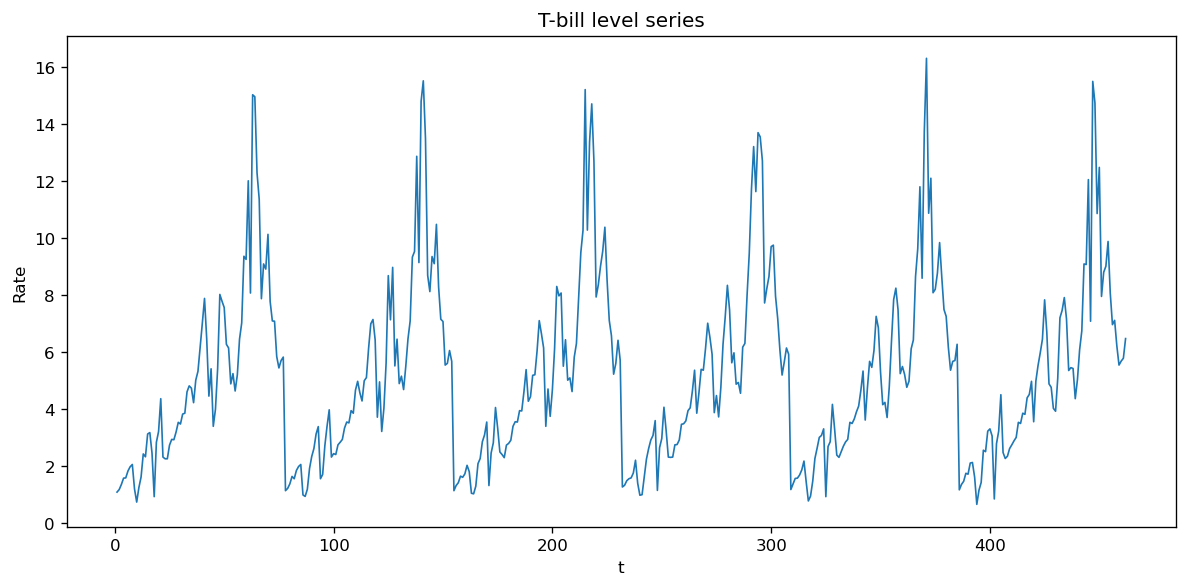

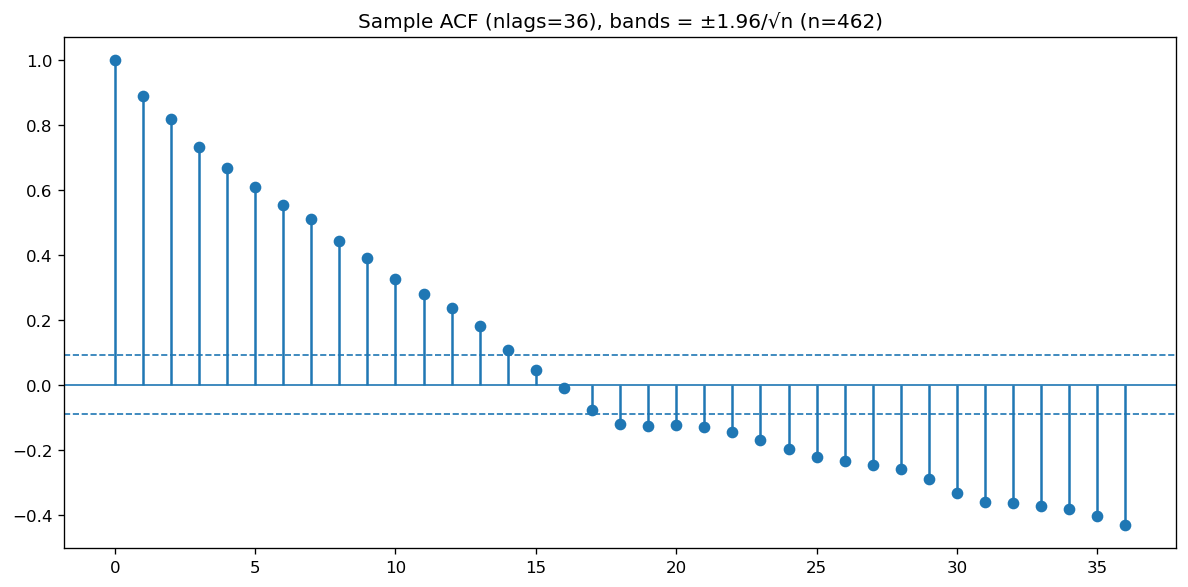

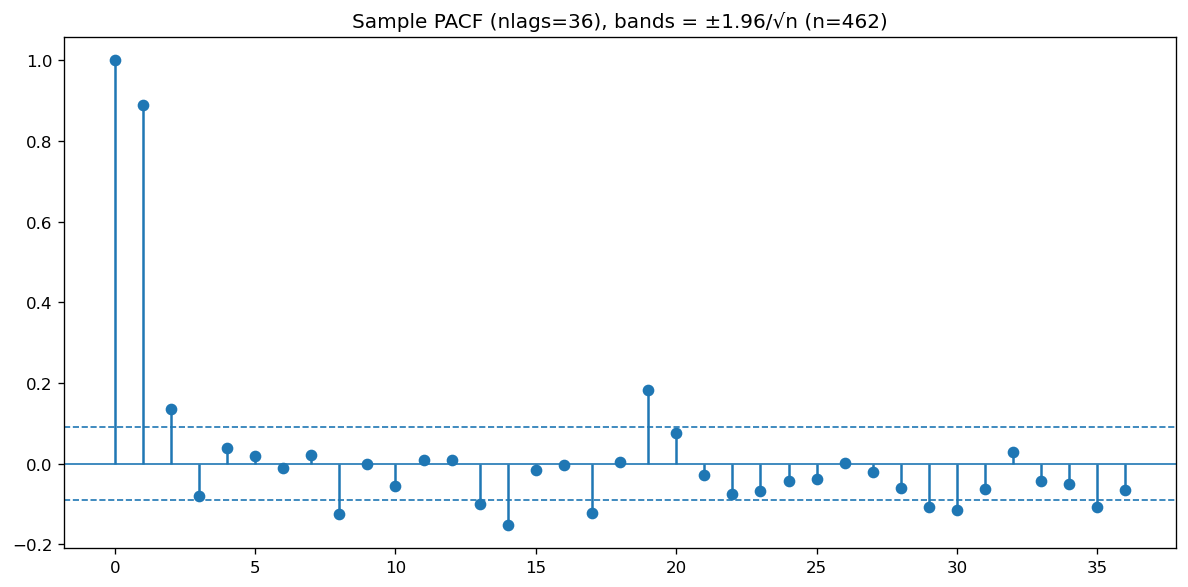

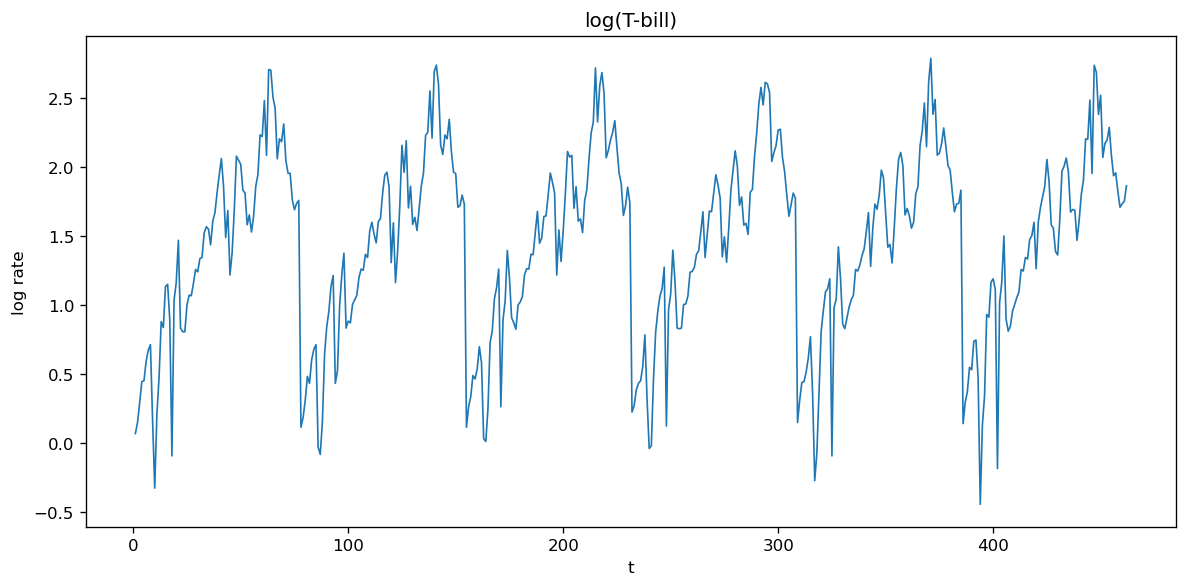

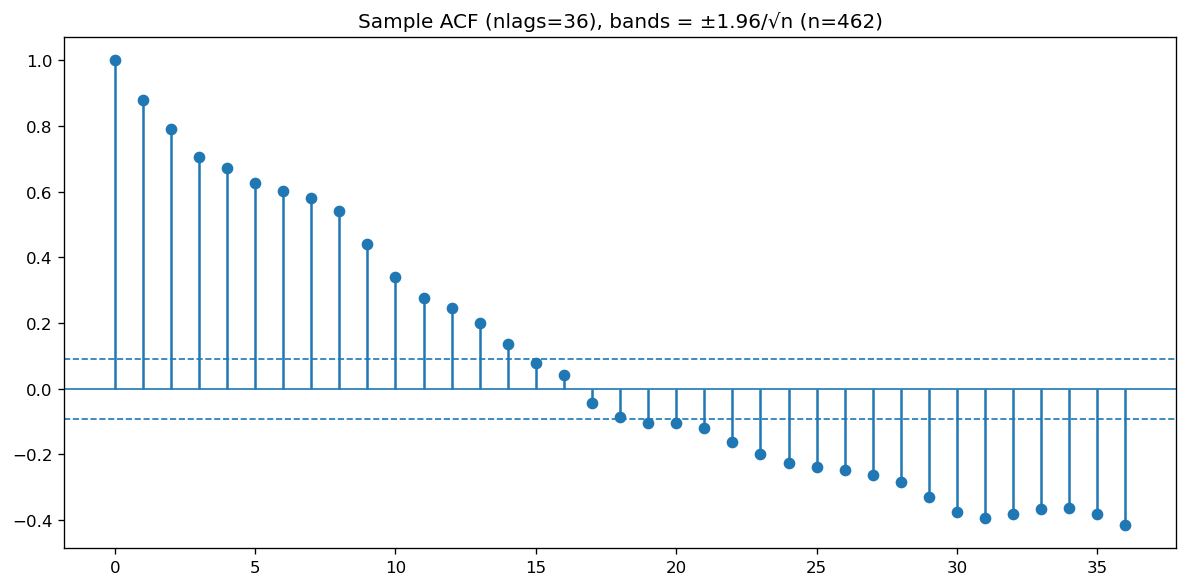

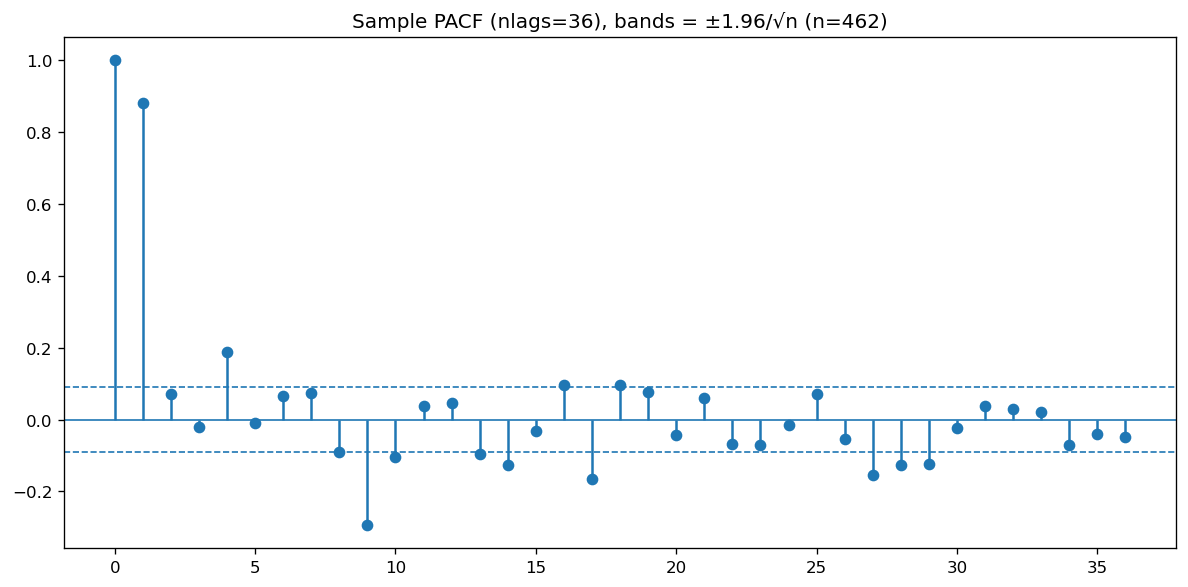

(array([ 1.    ,  0.8803,  0.7912,  0.705 ,  0.6711,  0.6276,  0.6021,
         0.5816,  0.5414,  0.4392,  0.341 ,  0.2762,  0.2467,  0.1985,
         0.1362,  0.0778,  0.04  , -0.0442, -0.0865, -0.1045, -0.1054,
        -0.1204, -0.162 , -0.2   , -0.2274, -0.2393, -0.2488, -0.264 ,
        -0.2852, -0.3294, -0.3751, -0.3944, -0.3812, -0.3652, -0.3624,
        -0.3805, -0.4157]),
 array([ 1.    ,  0.8803,  0.0719, -0.0211,  0.1879, -0.0111,  0.0645,
         0.0748, -0.0899, -0.2939, -0.1043,  0.0364,  0.0453, -0.0953,
        -0.1261, -0.033 ,  0.096 , -0.1655,  0.0974,  0.0758, -0.0422,
         0.0608, -0.0682, -0.0721, -0.0141,  0.0705, -0.0537, -0.1531,
        -0.1271, -0.1242, -0.0237,  0.0385,  0.0279,  0.0223, -0.0714,
        -0.0417, -0.0496]))

In [12]:
# ustbill.dat is assumed to be a table where the first column is dropped, then flattened column-wise by transpose.
tb = pd.read_table('ustbill.dat', header=None, sep='\s+')
tb_vals = tb.iloc[:, 1:].to_numpy()          # drop the first column
ttbill = tb_vals.T.reshape(-1).astype(float) # flatten like as.vector(t(.))

plot_series(ttbill, 'T-bill level series', ylabel='Rate')
plot_acf_pacf(ttbill, nlags=36)

lntbill = np.log(ttbill)
plot_series(lntbill, 'log(T-bill)', ylabel='log rate')
plot_acf_pacf(lntbill, nlags=36)

### Work with log-differences
We compute:
$$
d\ell_t = \Delta\log(T_t)
$$
and examine ACF/PACF. We try AR(6), MA(6), ARMA(6,6).

We demean the differenced log series before fitting with `trend='n'`.

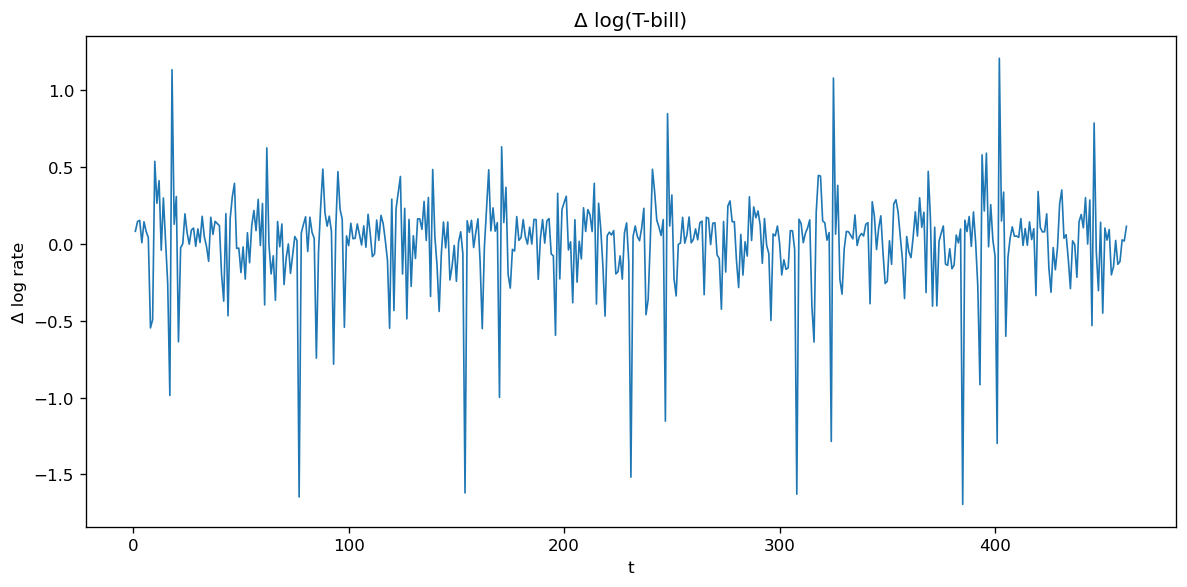

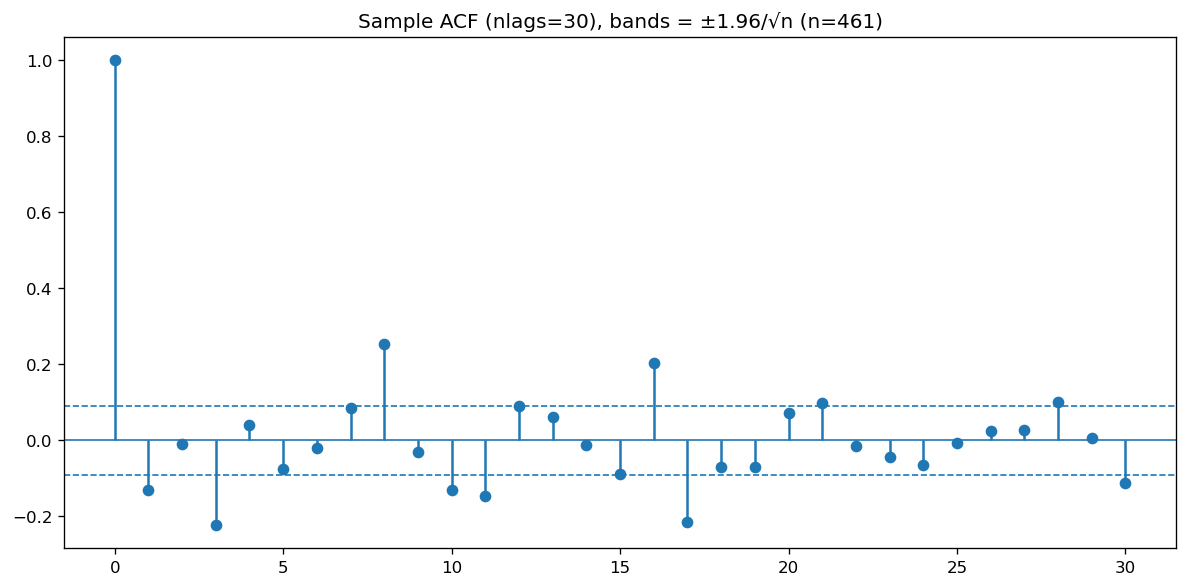

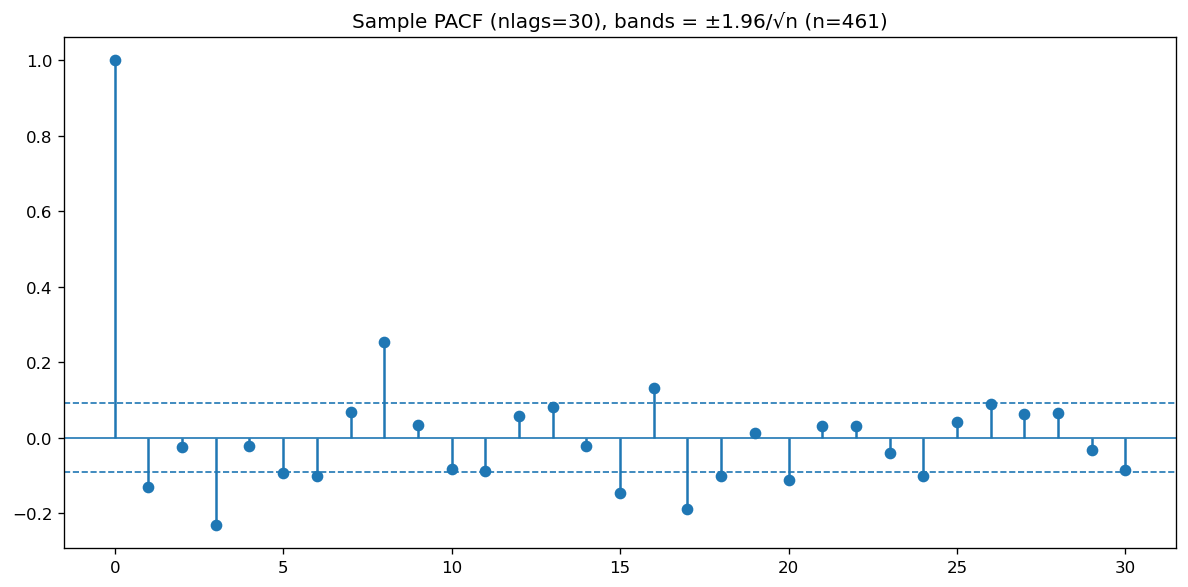

mean(Δlog) = 0.003900153295706498


In [13]:
dlntbill = np.diff(lntbill)
plot_series(dlntbill, 'Δ log(T-bill)', ylabel='Δ log rate')
plot_acf_pacf(dlntbill, nlags=30)

mu = float(np.mean(dlntbill))
x = dlntbill - mu
print('mean(Δlog) =', mu)

### Fit AR(6), MA(6), ARMA(6,6) and compare AIC
**Interpretation:** ARMA(6,6) tends to be preferred (AIC + diagnostics).

In [14]:
d3 = ARIMA(x, order=(6,0,0), trend='n').fit()   # AR(6)
d4 = ARIMA(x, order=(0,0,6), trend='n').fit()   # MA(6)
d5 = ARIMA(x, order=(6,0,6), trend='n').fit()   # ARMA(6,6)

cmp = pd.DataFrame({
    'model': ['AR(6)', 'MA(6)', 'ARMA(6,6)'],
    'AIC': [float(d3.aic), float(d4.aic), float(d5.aic)],
    'BIC': [float(d3.bic), float(d4.bic), float(d5.bic)]
}).sort_values('AIC')
cmp

C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,AIC,BIC
2,"ARMA(6,6)",195.534863,249.269038
0,AR(6),232.724417,261.658203
1,MA(6),236.917887,265.851673


### Diagnostics for the selected model
We check:
- residual ACF (should show no leftover correlation)
- Ljung–Box p-values (should not strongly reject whiteness)


Selected by AIC: ARMA(6,6)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  461
Model:                 ARIMA(6, 0, 6)   Log Likelihood                 -84.767
Date:                Tue, 10 Mar 2026   AIC                            195.535
Time:                        23:48:40   BIC                            249.269
Sample:                             0   HQIC                           216.692
                                - 461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1476      0.430     -0.343      0.731      -0.990       0.695
ar.L2         -0.6215      0.202     -3.071      0.002      -1.018      -0.225
ar.L3         -0.9776    

,lb_stat,lb_pvalue
6,0.533883,0.997401
12,3.180153,0.994133
18,38.079401,0.003781
24,48.562266,0.002149
30,62.523024,0.000451


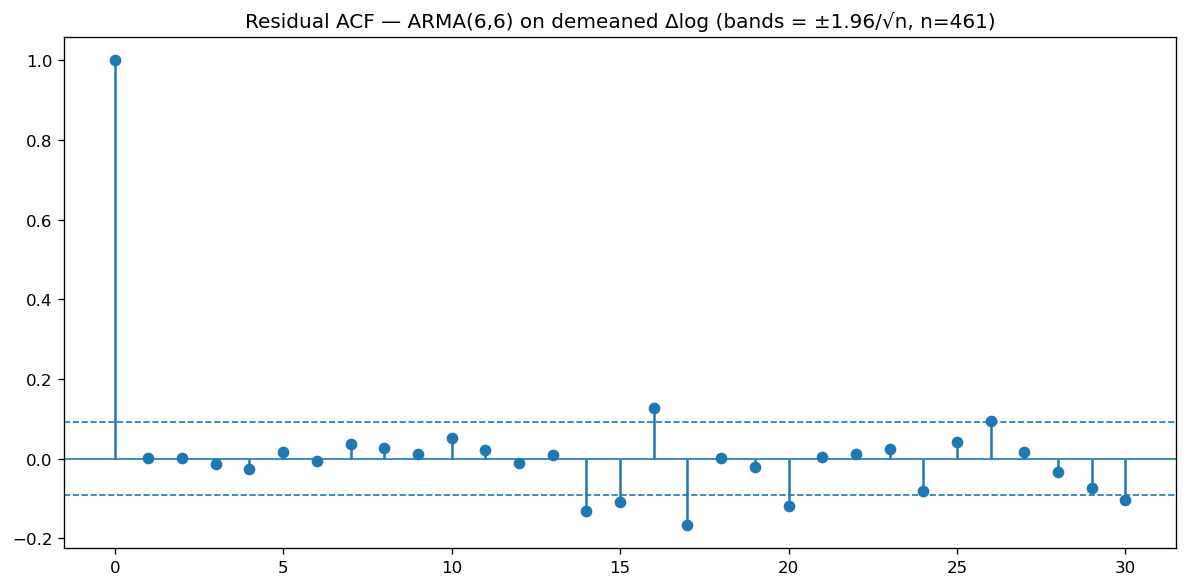

In [15]:
best_name = cmp.iloc[0]['model']
best_fit = {'AR(6)': d3, 'MA(6)': d4, 'ARMA(6,6)': d5}[best_name]
print('Selected by AIC:', best_name)
print(best_fit.summary())

resid_t, lb_t = residual_report(best_fit, lags=(6,12,18,24,30))
display(lb_t)
plot_resid_acf(resid_t, nlags=30, title=f'Residual ACF — {best_name} on demeaned Δlog')

### Forecasting: 6-step ahead and reconstruct level forecasts
We do a simple **holdout** evaluation:
- fit ARMA(6,6) on all but the last 6 differenced-log observations
- forecast the last 6, then reconstruct level forecasts multiplicatively
- compare with the actual last 6 level values

In [16]:
h = 6
N = len(ttbill)

dl = dlntbill
mu_dl = float(np.mean(dl))
x_dl = dl - mu_dl

train = x_dl[:-h]
actual_last6 = ttbill[-h:]

# Use ARMA(6,6)
fit_train = ARIMA(train, order=(6,0,6), trend='n').fit()
fc = fit_train.get_forecast(steps=h)
pred_x = np.asarray(fc.predicted_mean)

pred_dlog = pred_x + mu_dl
mult = np.exp(pred_dlog)

start_level = ttbill[-(h+1)]
tfore = np.zeros(h)
tfore[0] = start_level * mult[0]
for i in range(1, h):
    tfore[i] = tfore[i-1] * mult[i]

out = pd.DataFrame({'Actual': actual_last6, 'Forecast': tfore}, index=np.arange(N-h+1, N+1))
out

C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Actual,Forecast
457,7.10,6.808784
458,6.21,6.465065
459,5.53,6.530539
460,5.67,6.902406
461,5.77,7.496567
462,6.46,7.597183


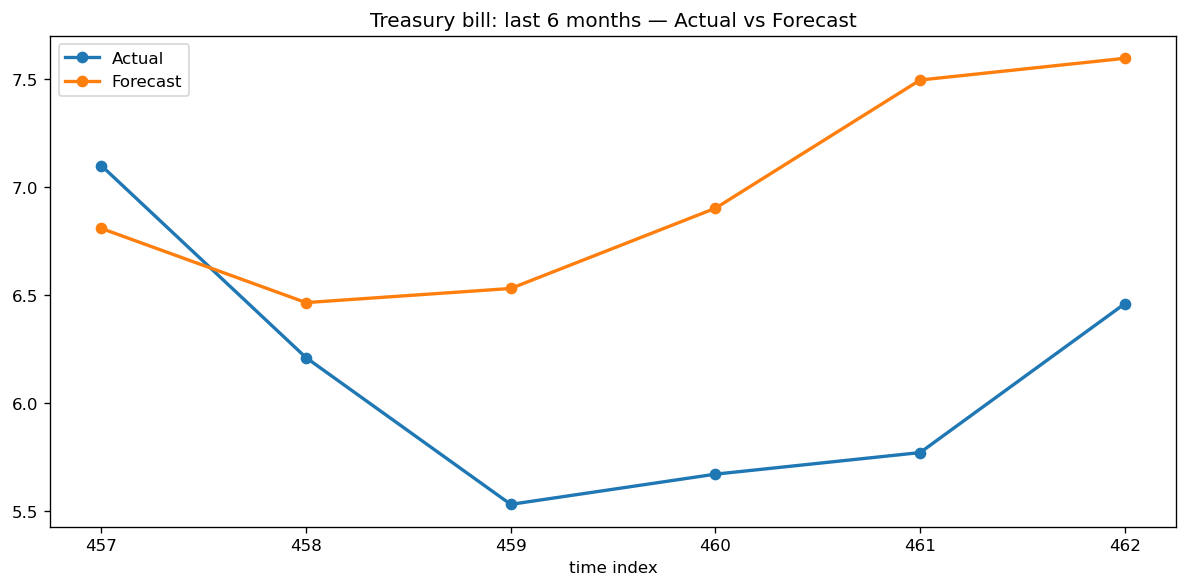

In [17]:
plt.figure(figsize=(10,5))
plt.plot(out.index, out['Actual'].values, marker='o', linewidth=2, label='Actual')
plt.plot(out.index, out['Forecast'].values, marker='o', linewidth=2, label='Forecast')
plt.title('Treasury bill: last 6 months — Actual vs Forecast')
plt.xlabel('time index')
plt.tight_layout()
plt.legend()
plt.show()

### Interpretation
- The first few months track well while later months deviate more: prediction variability grows with horizon, so longer-horizon forecasts deteriorate.
- This motivates reporting prediction intervals and being cautious about long-term forecasts.